In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


ISLR

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/Advertising.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


Text(0.5, 1.0, 'newspaper spend vs Sales')

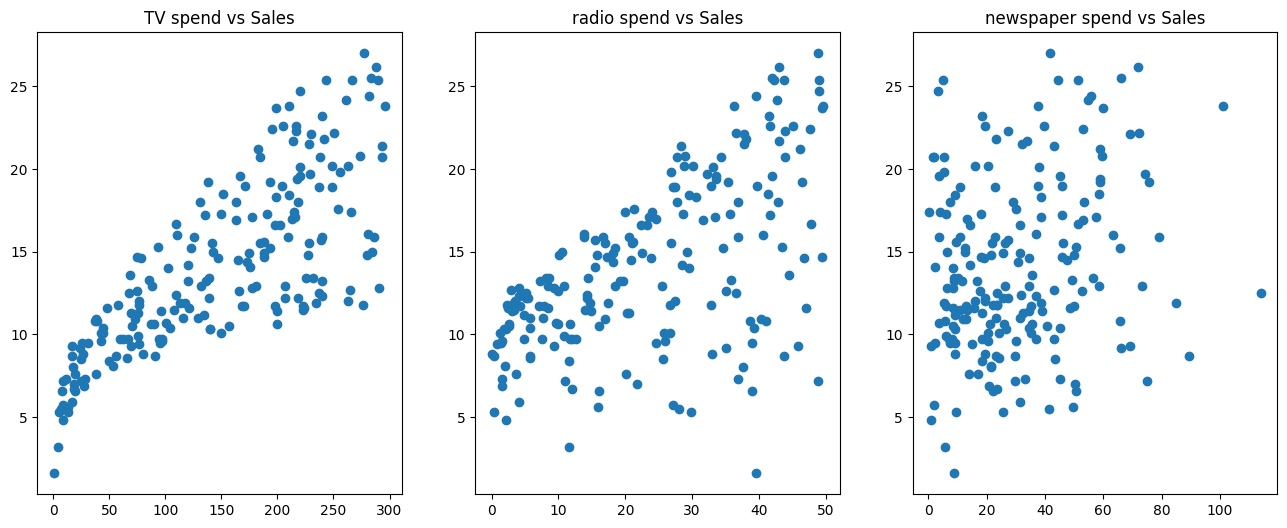

In [4]:
fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_title('TV spend vs Sales')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_title('radio spend vs Sales')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_title('newspaper spend vs Sales')

In [5]:
X= df.drop('sales',axis=1)
y = df['sales']

In [6]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [7]:
y

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


Train | Test Split

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=101)

In [47]:
X_train.shape

(140, 3)

In [48]:
X_test.shape

(60, 3)

# Create a model

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()

In [51]:
#Fit/Train the model on training data

model.fit(X_train,y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)

# Understanding and utilising Model

### Performance Analysis

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [54]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)

In [55]:
MAE

1.213745773614481

In [56]:
df['sales'].mean()

np.float64(14.0225)

In [57]:
1.2137/14

0.08669285714285714

In [58]:
MSE

2.2987166978863796

In [59]:
RMSE

np.float64(1.5161519375993884)

In [60]:
RMSE/14

np.float64(0.10829656697138489)

# Plotting Residuals

In [62]:
test_res = y_test - y_pred

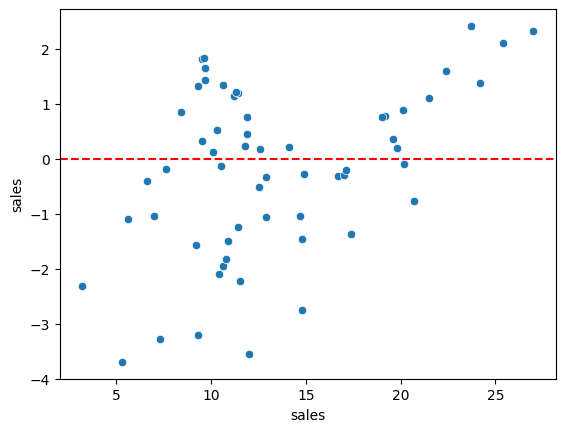

In [65]:
sns.scatterplot(x=y_test, y=test_res)
plt.axhline(y=0,color='red',ls='--')

<Axes: xlabel='sales', ylabel='Density'>

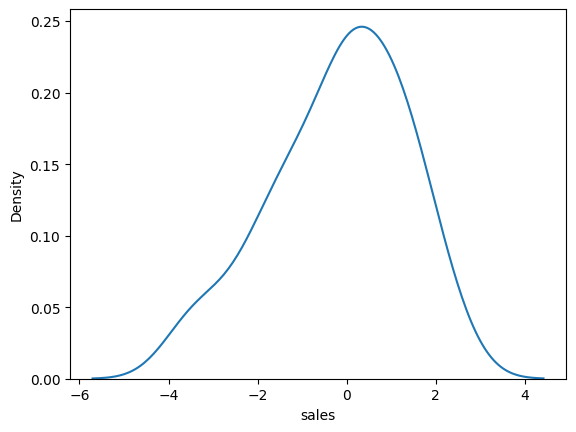

In [66]:
sns.kdeplot(test_res)

# Retraining Model on Full Data

In [67]:
final_model = LinearRegression()

In [68]:
final_model.fit(X,y)

LinearRegression()

In [71]:
y_hat = final_model.predict(X)

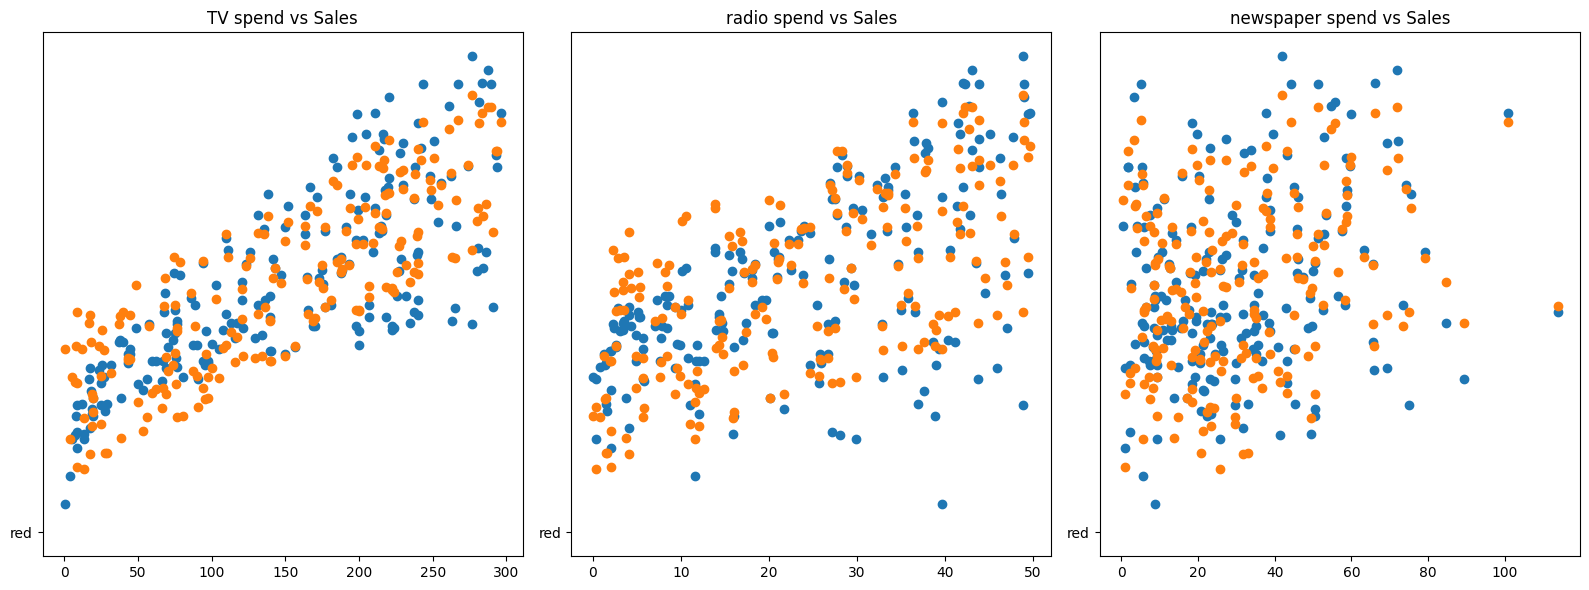

In [72]:
fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o','red')
axes[0].set_title('TV spend vs Sales')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o','red')
axes[1].set_title('radio spend vs Sales')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'o','red')
axes[2].set_title('newspaper spend vs Sales')

plt.tight_layout()
plt.show()

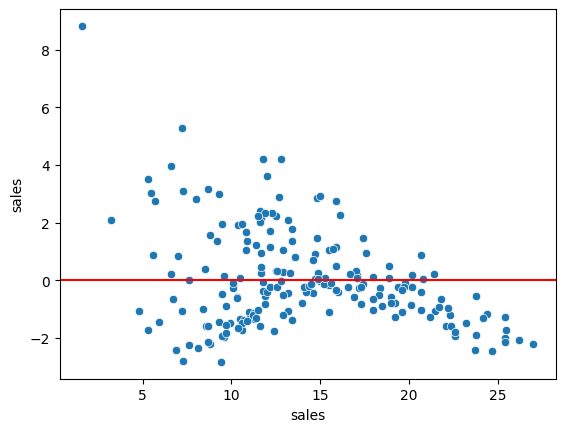

In [74]:
residuals = y_hat-y
sns.scatterplot(x=y,y=residuals)
plt.axhline(y=0,color='red')

# Interpretation of Coefficients

In [75]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [77]:
pd.DataFrame(final_model.coef_,X.columns,columns=['Coefficient'])

,Coefficient
TV,0.045765
radio,0.188530
newspaper,-0.001037


In [79]:
df.corr()['sales']

,sales
TV,0.782224
radio,0.576223
newspaper,0.228299
sales,1.000000


# prediction on New Data

In [84]:
ad_campaign = [[122,53,43],[122,53,9871],[222,153,0]]

final_model.predict(ad_campaign)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([18.46965481,  8.27317319, 41.94373325])

# Saving and Loading a Model

In [87]:
from joblib import dump, load

In [86]:
dump(final_model,'/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_model.joblib')

['/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_model.joblib']

In [88]:
loaded_model = load('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_model.joblib')

In [89]:
loaded_model.predict([[123,786,2871]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([153.77389153])